# Exploratory Data Analysis on FinTrust Digital Bank

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
print(pd.__version__)

2.2.2


In [36]:
print("NumPy version:", np.__version__)

NumPy version: 1.26.4


In [9]:
import os
print(os.getcwd())

C:\Users\USER\FinTrust EDA


In [10]:
customers=pd.read_excel('FinTrust_Customer_Data.xlsx')

In [11]:
print(customers.head())

  Customer_ID     Customer_Name  Age  Gender           City Customer_Segment  \
0   FT-C00001   Ibrahim Adeyemi   56    Male          Lagos          Premium   
1   FT-C00002    Yusuf Mohammed   46    Male           Kano         Everyday   
2   FT-C00003     Emeka Adeyemi   32  Female  Port Harcourt         Everyday   
3   FT-C00004    David Williams   60  Female     Benin City          Premium   
4   FT-C00005  Blessing Adeyemi   25    Male         Kaduna          Premium   

  Account_Type  Tenure_Months  Digital_Engagement_Score Monthly_Income_Band  \
0      Savings             55                      84.9           500k-999k   
1      Current             79                      50.7           500k-999k   
2      Savings             43                      56.1                 1m+   
3      Premium             44                      54.0           500k-999k   
4      Savings             68                      85.1           500k-999k   

  Preferred_Channel Account_Status  
0      

In [12]:
transactions=pd.read_excel('FinTrust_Transaction_Data.xlsx')

In [13]:
print(transactions.head())

  Transaction_ID Customer_ID Transaction_DateTime Transaction_Type  \
0     FT-T000001   FT-C01135  2026-01-01 00:00:00    Card Purchase   
1     FT-T000002   FT-C00428  2026-01-01 00:10:00  Cash Withdrawal   
2     FT-T000003   FT-C00469  2026-01-01 00:21:00         Transfer   
3     FT-T000004   FT-C01015  2026-01-01 00:32:00          Deposit   
4     FT-T000005   FT-C00870  2026-01-01 00:43:00  Cash Withdrawal   

   Amount_NGN     Channel   Device_Type Location International_Transaction  \
0     5923.80  Mobile App       Android    Enugu                        No   
1    11681.12         ATM       Android   Kaduna                        No   
2      571.91         ATM  POS Terminal     Kano                        No   
3   105367.52  Mobile App   Web Browser    Abuja                        No   
4     3049.06  Mobile App  POS Terminal    Abuja                        No   

  Transaction_Status Risk_Review_Flag  
0           Reversed              Yes  
1         Successful          

In [14]:
customers.shape

(1500, 12)

In [15]:
transactions.shape

(12000, 11)

In [17]:
customers.columns

Index(['Customer_ID', 'Customer_Name', 'Age', 'Gender', 'City',
       'Customer_Segment', 'Account_Type', 'Tenure_Months',
       'Digital_Engagement_Score', 'Monthly_Income_Band', 'Preferred_Channel',
       'Account_Status'],
      dtype='object')

In [18]:
transactions.columns

Index(['Transaction_ID', 'Customer_ID', 'Transaction_DateTime',
       'Transaction_Type', 'Amount_NGN', 'Channel', 'Device_Type', 'Location',
       'International_Transaction', 'Transaction_Status', 'Risk_Review_Flag'],
      dtype='object')

## Checking for Data types


In [21]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               1500 non-null   object 
 1   Customer_Name             1500 non-null   object 
 2   Age                       1500 non-null   int64  
 3   Gender                    1500 non-null   object 
 4   City                      1500 non-null   object 
 5   Customer_Segment          1500 non-null   object 
 6   Account_Type              1500 non-null   object 
 7   Tenure_Months             1500 non-null   int64  
 8   Digital_Engagement_Score  1500 non-null   float64
 9   Monthly_Income_Band       1500 non-null   object 
 10  Preferred_Channel         1500 non-null   object 
 11  Account_Status            1500 non-null   object 
dtypes: float64(1), int64(2), object(9)
memory usage: 140.8+ KB


In [20]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Transaction_ID             12000 non-null  object        
 1   Customer_ID                12000 non-null  object        
 2   Transaction_DateTime       12000 non-null  datetime64[ns]
 3   Transaction_Type           12000 non-null  object        
 4   Amount_NGN                 12000 non-null  float64       
 5   Channel                    12000 non-null  object        
 6   Device_Type                11904 non-null  object        
 7   Location                   11904 non-null  object        
 8   International_Transaction  12000 non-null  object        
 9   Transaction_Status         12000 non-null  object        
 10  Risk_Review_Flag           12000 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(9)
memory usage: 1.0+ MB


## Statistical Analysis

In [23]:
customers.describe()

,Age,Tenure_Months,Digital_Engagement_Score
count,1500.000000,1500.000000,1500.000000
mean,41.587333,49.858667,67.954000
std,13.733127,27.910990,17.555376
min,18.000000,1.000000,16.700000
25%,29.750000,26.000000,56.100000
50%,42.000000,51.000000,68.000000
75%,53.000000,74.000000,80.925000
max,65.000000,96.000000,100.000000


In [24]:
transactions.describe()

,Transaction_DateTime,Amount_NGN
count,12000,12000.000000
mean,2026-02-14 23:59:29.510000128,46706.446238
min,2026-01-01 00:00:00,100.170000
25%,2026-01-23 11:59:15,2192.220000
50%,2026-02-14 23:59:30,10305.935000
75%,2026-03-09 11:59:45,48484.475000
max,2026-03-31 23:59:00,693454.450000
std,NaN,86028.715234


## Missing values


In [25]:
customers.isnull().sum()

Customer_ID                 0
Customer_Name               0
Age                         0
Gender                      0
City                        0
Customer_Segment            0
Account_Type                0
Tenure_Months               0
Digital_Engagement_Score    0
Monthly_Income_Band         0
Preferred_Channel           0
Account_Status              0
dtype: int64

the customer data has no missing values.

In [26]:
transactions.isnull().sum()

Transaction_ID                0
Customer_ID                   0
Transaction_DateTime          0
Transaction_Type              0
Amount_NGN                    0
Channel                       0
Device_Type                  96
Location                     96
International_Transaction     0
Transaction_Status            0
Risk_Review_Flag              0
dtype: int64

96 missing values were found in the device type and location columns each

## Duplicate values

In [27]:
customers.duplicated().sum()

0

In [28]:
transactions.duplicated().sum()

0

no duplicates found in the both datasets

In [31]:
customers["Customer_ID"].duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1495    False
1496    False
1497    False
1498    False
1499    False
Name: Customer_ID, Length: 1500, dtype: bool

no duplicates were found in the customer_id column

In [ ]:
transactions["Transaction_ID"].duplicated()

no duplicate transaction ids were found

In [34]:
print("CUSTOMER COLUMNS")
print(customers.columns.tolist())

CUSTOMER COLUMNS
['Customer_ID', 'Customer_Name', 'Age', 'Gender', 'City', 'Customer_Segment', 'Account_Type', 'Tenure_Months', 'Digital_Engagement_Score', 'Monthly_Income_Band', 'Preferred_Channel', 'Account_Status']


In [35]:
print("TRANSACTION COLUMNS")
print(transactions.columns.tolist())

TRANSACTION COLUMNS
['Transaction_ID', 'Customer_ID', 'Transaction_DateTime', 'Transaction_Type', 'Amount_NGN', 'Channel', 'Device_Type', 'Location', 'International_Transaction', 'Transaction_Status', 'Risk_Review_Flag']


## Question 1: Customer segment Analysis

In [40]:
customers["Customer_Segment"]. value_counts()

Customer_Segment
Everyday    711
Premium     295
Student     278
SME         216
Name: count, dtype: int64

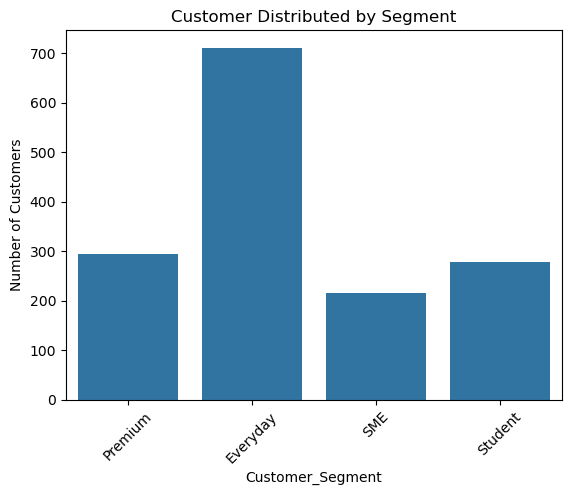

In [41]:
sns.countplot(data=customers, x="Customer_Segment")
plt.title("Customer Distributed by Segment")
plt.xlabel("Customer_Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

The visualization reveals the distribution of FinTrust customers across the identified customer segments.These differences can support more targeted customer engagement and service strategies.

## Importance
This helps the business understand its customer composition and identify segments that represent a larger proportion of its customer base.

## Business insight
FinTrust can use this information to tailor products, services, communication, and marketing strategies to different customer groups based on its largest segment, which the Everyday segment, and smallest customer segments, which is the SME.

## Question 2: Transaction type analysis

In [42]:
transactions["Transaction_Type"]. value_counts()

Transaction_Type
Transfer           3549
Card Purchase      3033
Bill Payment       1475
Cash Withdrawal    1430
Deposit            1328
Airtime/Data       1185
Name: count, dtype: int64

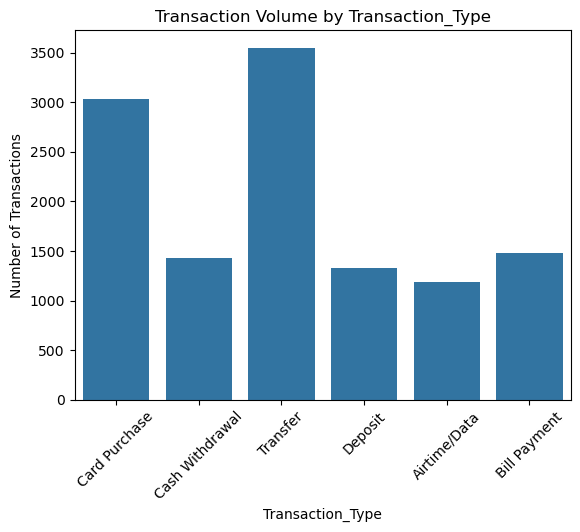

In [43]:
sns.countplot(data=transactions, x="Transaction_Type")
plt.title("Transaction Volume by Transaction_Type")
plt.xlabel("Transaction_Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

The transaction-type analysis highlights the financial activities customers perform most frequently.It shows that Transfer is the mostly used transaction type by customers. 

## Importannce
This provides an indication of which services generate the greatest transaction activity and can help FinTrust prioritize service optimization and customer experience improvements..

## Business insight
The dominant transaction type indicates the services customers rely on most. FinTrust can prioritize these services to improve their user experience, and investigate the transaction types with unusually low or high activity.

## Question 3: Transaction Amount Analysis

In [47]:
transactions["Amount_NGN"]. describe()

count     12000.000000
mean      46706.446238
std       86028.715234
min         100.170000
25%        2192.220000
50%       10305.935000
75%       48484.475000
max      693454.450000
Name: Amount_NGN, dtype: float64

## Total Transaction Amount by Transaction Type

In [53]:
transactions.groupby("Transaction_Type")["Amount_NGN"].sum()

Transaction_Type
Airtime/Data       9.776171e+06
Bill Payment       2.816365e+07
Card Purchase      8.586341e+07
Cash Withdrawal    6.777236e+07
Deposit            1.309851e+08
Transfer           2.379167e+08
Name: Amount_NGN, dtype: float64

## Average Transaction Amount by Transaction Type

In [55]:
transactions.groupby("Transaction_Type")["Amount_NGN"].mean()

Transaction_Type
Airtime/Data        8249.933494
Bill Payment       19093.998312
Card Purchase      28309.730887
Cash Withdrawal    47393.260217
Deposit            98633.328200
Transfer           67037.672699
Name: Amount_NGN, dtype: float64

In [57]:
transaction_value = (
    transactions
    .groupby("Transaction_Type")["Amount_NGN"]
    .sum()
    .sort_values(ascending=False)
)

In [96]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate total transaction amount
total_amount = transactions["Amount_NGN"].sum()

print(f"Total Transaction Amount: ₦{total_amount:,.2f}")

Total Transaction Amount: ₦560,477,354.85


## This shows the overall Total Transaction amount generated by FinTrust customer base

### a. Total Transaction Value by Transaction Type

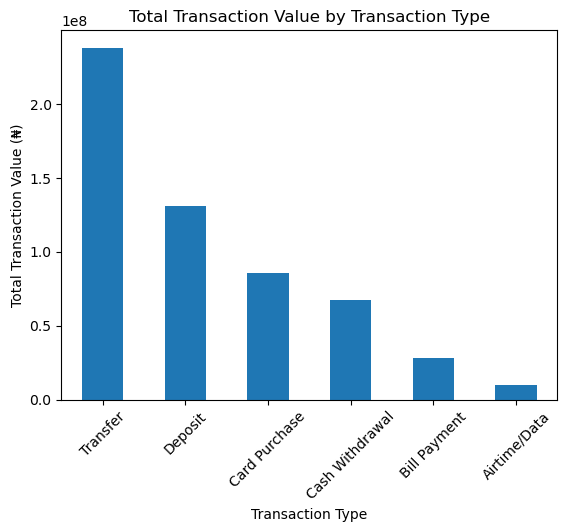

In [58]:
transaction_value.plot(kind="bar")

plt.title("Total Transaction Value by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Total Transaction Value (₦)")
plt.xticks(rotation=45)
plt.show()

## What the Visual shows
The transaction-type analysis highlights the financial activities customers perform most frequently. Transfers account for the largest share of total transaction value, indicating that they represent a significant portion of the monetary activity within the FinTrust transaction dataset.

## Importance
This provides an indication of which services generate the greatest transaction activity and can help FinTrust prioritize service optimization and customer experience improvements.

## Business Insight
FinTrust can make better decisions to improve their services in the areas where transaction is low so as to get more customers to use them.

## Question 4: Transaction channels

In [59]:
transactions["Channel"].value_counts()

Channel
Mobile App    5102
POS           2393
Web           1869
ATM           1747
USSD           889
Name: count, dtype: int64

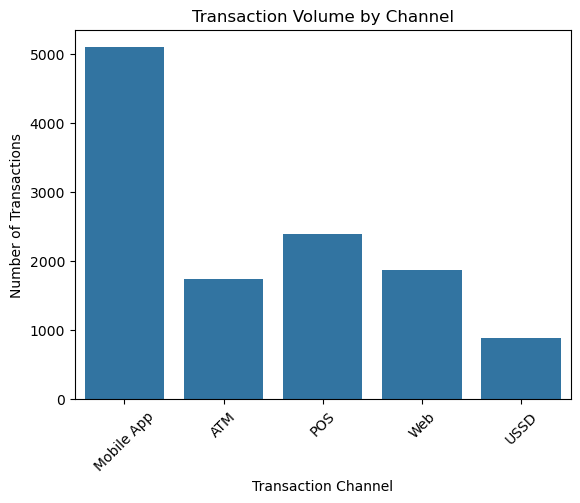

In [60]:
sns.countplot(
    data=transactions,
    x="Channel")

plt.title("Transaction Volume by Channel")
plt.xlabel("Transaction Channel")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

## What the Visual shows:
It shows which channels customers use to perform transactions, such as mobile, web, ATM, branch, or other available channels. It indicates Mobile App channel is the most common channel used by the customers.

## Why it is Important
Helps FinTrust understand how customers interact with its banking services.

## Business Insight
FinTrust can prioritize digital reliability and user experience. Low-use channels may require further investigation to understand whether customers face accessibility or usability issues.

## Question 5: Transaction Status

In [62]:
transactions["Transaction_Status"].value_counts()

Transaction_Status
Successful    10856
Failed          630
Reversed        326
Pending         188
Name: count, dtype: int64

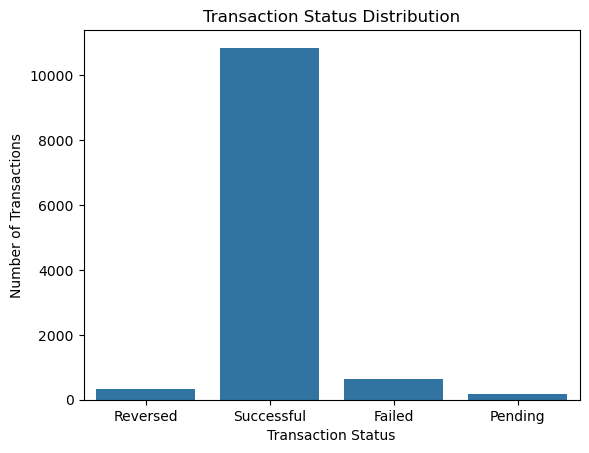

In [63]:
sns.countplot(
    data=transactions,
    x="Transaction_Status"
)

plt.title("Transaction Status Distribution")
plt.xlabel("Transaction Status")
plt.ylabel("Number of Transactions")
plt.show()

## What the Visual Shows:
Shows the proportion or number of successful, failed, pending, reversed, or other transaction statuses. Successful transactions are the highest in the distribution.

## Why it is important
Provides an indication of transaction reliability and potential operational problems.

## Business insight
The high successful-transaction rate may indicate that most transactions are being completed as expected.

## Question 6: International Transactions

In [66]:
transactions["International_Transaction"].value_counts()

International_Transaction
No     11520
Yes      480
Name: count, dtype: int64

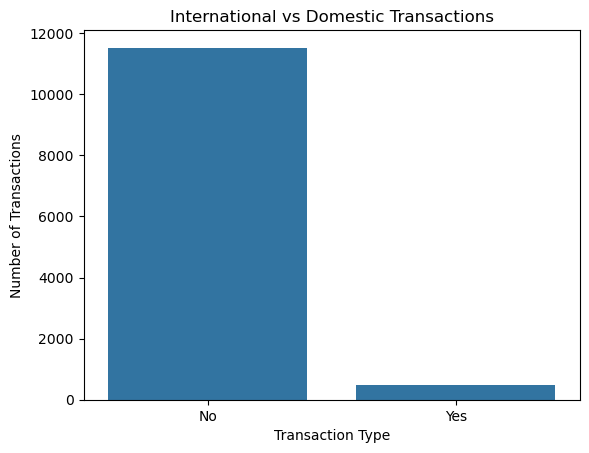

In [68]:
sns.countplot(
    data=transactions,
    x="International_Transaction")

plt.title("International vs Domestic Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.show()

## What the visual shows
Shows international versus domestic transaction activity. It is seen that domestic transactions have the highest values.

## Why it is important
This is because International transactions can involve different customer behaviours, transaction values, currencies, and risk considerations.

## Business Insight
FinTrust can identify how significant international activity is within its customer base and determine whether certain customer segments or channels are responsible for a large share of domestic transactions.

In [69]:
transactions.groupby("International_Transaction")["Amount_NGN"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
International_Transaction,,,
No,11520,5.404816e+08,46916.803036
Yes,480,1.999578e+07,41657.883063


## Question 7: Customer Behaviour Analysis
This analysis shows the customer behaviour patterns across the different transaction types, channel and device types.

In [106]:
transactions.groupby("Channel")["Amount_NGN"].sum()

Channel
ATM           8.394235e+07
Mobile App    2.401044e+08
POS           1.043467e+08
USSD          4.275895e+07
Web           8.932500e+07
Name: Amount_NGN, dtype: float64

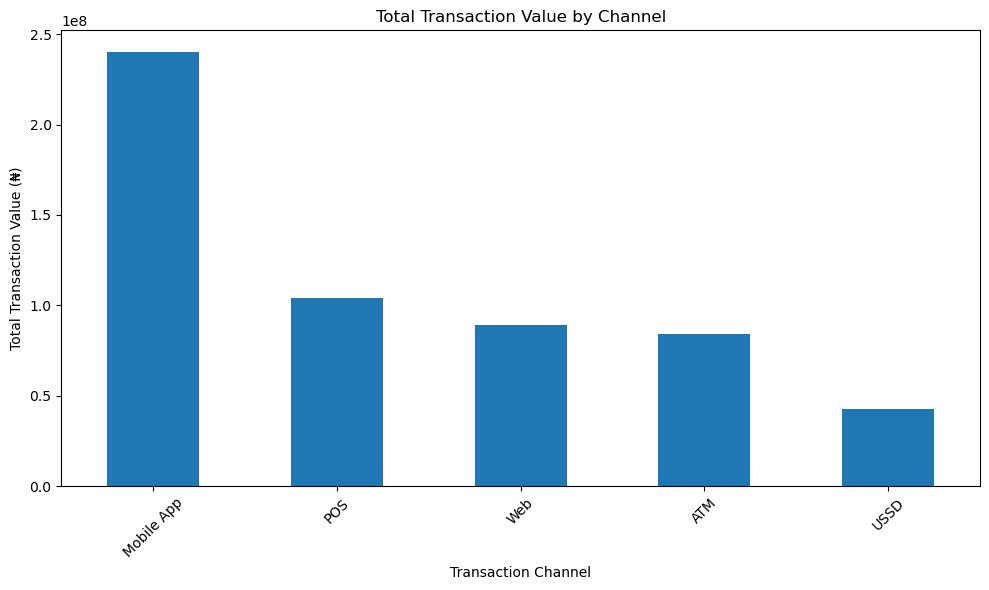

In [115]:
import matplotlib.pyplot as plt

channel_value = transactions.groupby("Channel")["Amount_NGN"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
channel_value.plot(kind="bar")

plt.title("Total Transaction Value by Channel")
plt.xlabel("Transaction Channel")
plt.ylabel("Total Transaction Value (₦)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [117]:
transactions.groupby("Device_Type")["Amount_NGN"].sum()

Device_Type
ATM Terminal    5.578360e+07
Android         2.255744e+08
POS Terminal    7.393414e+07
Web Browser     6.687923e+07
iOS             1.331492e+08
Name: Amount_NGN, dtype: float64

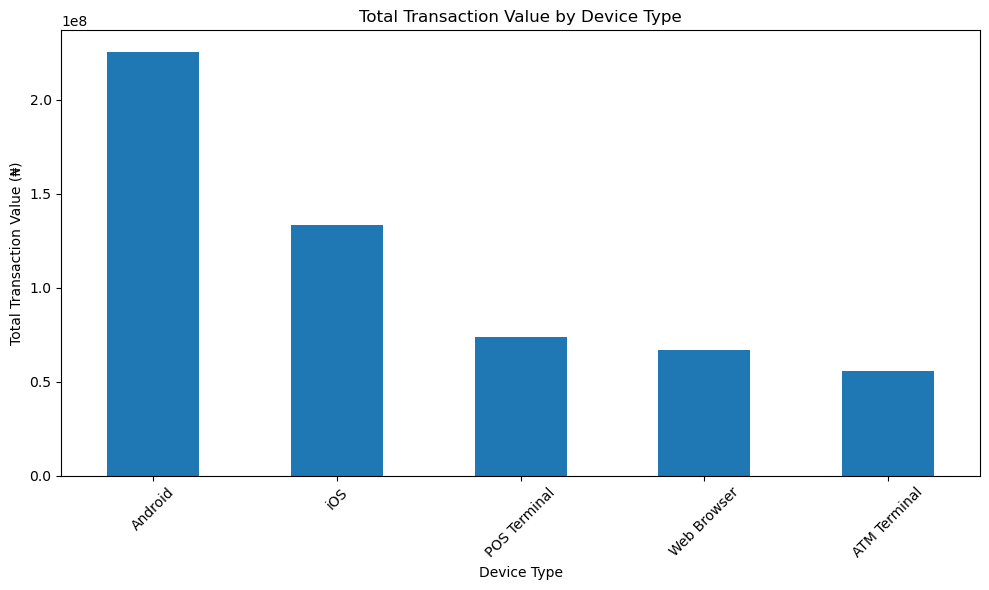

In [112]:
device_value = transactions.groupby("Device_Type")["Amount_NGN"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
device_value.plot(kind="bar")

plt.title("Total Transaction Value by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Total Transaction Value (₦)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The charts above answers the question of which combinations of transaction channels and devices generate the highest transaction value? The analysis shows that mobile transactions performed through smartphones account for a significant share of total transaction value. This suggests that smartphones are an important channel-device combination for customer financial activity, making the reliability, security, and usability of the mobile experience particularly important for FinTrust.

## The importance
It helps FinTrust understand how customers prefer to carry out higher-value transactions.

## Business Insight
For the transaction value by channel analysis, The mobile app channel has the highest transaction value across all the channels, showing that most customers performed transactions more with the mobile app. While the transaction by device type shows that android users have the largest transaction value.

This will help FinTrust carry out investigations on why some channels and device types perform better than other channels, and how they can improve their services on them so as to encourage more usage.

## Question 8: Risk review patterns

In [82]:
transactions["Risk_Review_Flag"].value_counts()

Risk_Review_Flag
No     9648
Yes    2352
Name: count, dtype: int64

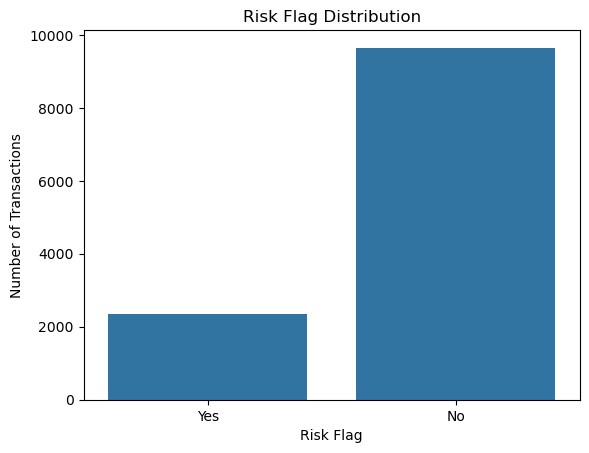

In [83]:
sns.countplot(
    data=transactions,
    x="Risk_Review_Flag"
)

plt.title("Risk Flag Distribution")
plt.xlabel("Risk Flag")
plt.ylabel("Number of Transactions")
plt.show()

The risk review patterns show the relationship between transactions/customer behaviour and risk flags or transactions requiring review.

The risk flag distribution shows that the transactions without risk flag are greater in value than those with the risk flag.

## The Importance
Helps FinTrust understand where potentially risky activity is concentrated and supports monitoring and risk-management processes.

## Business Insight
FinTrust can identify patterns such as particular transaction types, channels, customer segments, or international transactions that have risk-flagged transactions. These patterns can help prioritize further investigations to uncover why it was flagged as risk.